In [5]:
import pandas as pd
import certifi
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from dotenv import load_dotenv
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_curve, auc)

# set up logging
logging.basicConfig(
    filename="pipeline.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

In [6]:
# this queries the database created in load_data.ipynb

try:
    load_dotenv()
    MONGO_URI = os.getenv("MONGO_URI")
    client = MongoClient(MONGO_URI, tlsCAFile=certifi.where())
    db = client["fake_reviews_db"]
    collection = db["reviews"]

    cursor = collection.find({}, {"_id": 0, "category": 1, "rating": 1, 
                                   "label": 1, "text_": 1})
    
    df = pd.DataFrame(list(cursor))
    logging.info(f"Loaded {len(df)} documents from MongoDB")
    print(f"Loaded {len(df)} documents from MongoDB")
    print(df.head())

except Exception as e:
    logging.error(f"Failed to load data: {e}")
    print(f"Error: {e}")

Loaded 28000 documents from MongoDB
             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information on how to use it, but it i...  
4  Very nice set. Good quality. We have had the s...  


In [9]:
df["text_length"] = df["text_"].apply(lambda x: len(x.split()))
print("\nAverage text length by label:")
print(df.groupby("label")["text_length"].mean())

logging.info("Data preparation complete")


Average text length by label:
label
CG    59.068000
OR    70.919214
Name: text_length, dtype: float64


In [12]:
try:
    df["label_binary"] = df["label"].apply(lambda x: 1 if x == "CG" else 0)

    # TF-IDF vectorization converts text to numerical features
    # max_features=10000 keeps the most meaningful words
    # ngram_range=(1,2) captures both single words and two-word phrases
    vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), 
                                  stop_words="english")
    X = vectorizer.fit_transform(df["text_"])
    y = df["label_binary"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    logging.info("Model training complete")
    print("Model trained successfully")

except Exception as e:
    logging.error(f"Model training failed: {e}")
    print(f"Error: {e}")

Model trained successfully


For this project, TF-IDF (Term Frequency-Inverse Document Frequency) combined with Logistic Regression was chosen as the primary model. It is typically the standard baseline for text classification tasks and has been validated in prior research on AI text detection. TF-IDF works by converting raw review text into numerical features that capture how important each word is relative to the entire dataset, which was useful in this case as fake and human reviews tend to use different vocabulary and patterns. Logistic Regression was chosen over more complex models like neural networks because it is interpretable, fast to train on 40,000 documents, and does well on high-dimensional sparse data like TF-IDF vectors. Bigrams (ngram_range=(1,2)) were also used in addition to unigrams because this makes it possible to capture two-word phrases like "highly recommend" or "great product" which are common in fake reviews. 

Additionally, the 80/20 train-test split with stratification ensures that both classes are equally represented in training and testing. Precision, recall, and F1-score were also prioritized over raw accuracy because in a real-world fake review detection system, both false positives and false negatives carry meaningful consequences.

In [13]:
try:
    y_pred = model.predict(X_test)

    print("=== Classification Report ===")
    print(classification_report(y_test, y_pred, 
                                 target_names=["Human (OR)", "Fake (CG)"]))

    logging.info("Model evaluation complete")

except Exception as e:
    logging.error(f"Evaluation failed: {e}")
    print(f"Error: {e}")

=== Classification Report ===
              precision    recall  f1-score   support

  Human (OR)       0.88      0.90      0.89      2800
   Fake (CG)       0.90      0.88      0.89      2800

    accuracy                           0.89      5600
   macro avg       0.89      0.89      0.89      5600
weighted avg       0.89      0.89      0.89      5600



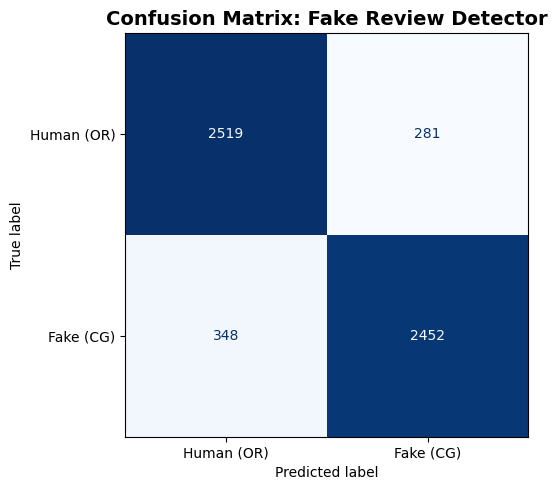

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                display_labels=["Human (OR)", "Fake (CG)"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix: Fake Review Detector", 
                fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

The confusion matrix was chosen as the primary visualization for model results because it provides a very complete picture of classifier performance for a binary detection task like this. Unlike a single accuracy number, the confusion matrix breaks down predictions into four categories: true positives (fake reviews correctly flagged), true negatives (real reviews correctly cleared), false positives (real reviews wrongly flagged as fake), and false negatives (fake reviews that slipped through undetected).

The model performed well overall, correctly classifying the majority of both human and AI-generated reviews. Of the 2,800 human-written reviews in the test set, 2,519 were correctly identified as human (true negatives) and 281 were incorrectly flagged as fake (false positives), giving a precision of around 90% for the human class. Of the 2,800 AI-generated reviews, 2,452 were correctly identified as fake (true positives) and 348 slipped through undetected as human (false negatives), giving a recall of around 88% for the fake class. The overall accuracy of the model sits at approximately 89%, meaning the model is performing well. The false negative rate of 12% is a little concerning from a practical standpoint, as these are the reviews that would successfully deceive the model on a real platform. The false positive rate of 10% is also significant, as incorrectly flagging legitimate reviews could frustrate customers and undermine trust in the detection system.